# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

## Initialization

In [ ]:
# Loading all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import math

## Load data

In [ ]:
## Load the data files into different DataFrames ##
df_calls = pd.read_csv("/datasets/megaline_calls.csv")
df_internet = pd.read_csv("/datasets/megaline_internet.csv")
df_messages = pd.read_csv("/datasets/megaline_messages.csv")
df_plans = pd.read_csv("/datasets/megaline_plans.csv")
df_users = pd.read_csv("/datasets/megaline_users.csv")

## Prepare the data

## Plans

In [ ]:
## Print the general/summary information about the plans' DataFrame ##

df_plans.describe(include = 'all')

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
count,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ultimate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000,NaN
std,671.751442,10861.160159,1767.766953,35.355339,2.12132,0.014142,0.014142,NaN
min,50.000000,15360.000000,500.000000,20.000000,7.00000,0.010000,0.010000,NaN
25%,287.500000,19200.000000,1125.000000,32.500000,7.75000,0.015000,0.015000,NaN
50%,525.000000,23040.000000,1750.000000,45.000000,8.50000,0.020000,0.020000,NaN
75%,762.500000,26880.000000,2375.000000,57.500000,9.25000,0.025000,0.025000,NaN


In [ ]:
## plan info ##

df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:
## Print a sample of data for plans ##

df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


------------------------------------------------------------------------------------------

There are no missing values in the dataset. I will convert the MB column to GB, as this may be useful for later analysis.

------------------------------------------------------------------------------------------

## Fix data

In [ ]:
## megabytes to gigabytes function ##

def mb_to_gb_ceil(mb):
    '''This function will convert mb to gb and do ceiling rounding'''
    conversation_factor = 1/1024
    return math.ceil( conversation_factor * mb)

df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Enrich data

-----

No needed for additional factors here. The dataset looks fine.

-----

## Users

In [ ]:
# Print the general/summary information about the users' DataFrame

df_users.describe(include = 'all')

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
count,500.000000,500,500,500.000000,500,500,500,34
unique,NaN,458,399,NaN,73,266,2,29
top,NaN,Jasper,Brock,NaN,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-29,surf,2018-12-18
freq,NaN,3,3,NaN,80,5,339,3
mean,1249.500000,NaN,NaN,45.486000,NaN,NaN,NaN,NaN
std,144.481833,NaN,NaN,16.972269,NaN,NaN,NaN,NaN
min,1000.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN
25%,1124.750000,NaN,NaN,30.000000,NaN,NaN,NaN,NaN
50%,1249.500000,NaN,NaN,46.000000,NaN,NaN,NaN,NaN
75%,1374.250000,NaN,NaN,61.000000,NaN,NaN,NaN,NaN


-----

The **churn_date** column contains 34 non-null values.
Since the churn date represents when a customer cancels their prepaid plan, this indicates that 34 out of the 500 customers canceled their plan.

The first name **Leonila** appears three times. This may indicate that three different customers share the same first name; however, further investigation is needed to confirm this.

Similarly, the last name **Velazquez** appears three times. This may indicate multiple customers share the same last name, but additional verification is required.

The average age of customers is approximately 45.5 years, with a standard deviation of about 17 years. Assuming the age distribution is approximately normal, most customers are likely between roughly 28 and 62 years old (1 standard deviation within the mean).

The youngest and oldest customers in the sample are 18 and 75 years old, respectively.

There are 73 unique cities represented in the dataset. The most common city is the **New York–Newark–Jersey City, NY–NJ–PA** metropolitan area.

The most common registration date is **June 4, 2018** (appearing five times).

The most common prepaid plan is **Surf**, with 339 out of the 500 in the sample.

-----

In [ ]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


-----

The churn_date column contains **34 non-null values** out of 500 observations, indicating that only **34 customers** have recorded churn dates.

-----

In [ ]:
# Print a sample of data for users

df_users.sample(10,random_state=9)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
370,1370,Nenita,Vasquez,49,"San Diego-Chula Vista-Carlsbad, CA MSA",2018-09-12,ultimate,NaN
256,1256,Johnny,Wise,53,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-09-11,surf,NaN
124,1124,Jenell,Navarro,48,"New Haven-Milford, CT MSA",2018-02-19,ultimate,NaN
320,1320,Bert,Wells,23,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-02-23,surf,NaN
322,1322,Tyler,Sweeney,22,"Fresno, CA MSA",2018-06-18,surf,NaN
194,1194,Robert,Mclean,40,"San Jose-Sunnyvale-Santa Clara, CA MSA",2018-05-31,surf,NaN
276,1276,Karmen,Carney,20,"Phoenix-Mesa-Chandler, AZ MSA",2018-02-14,surf,NaN
379,1379,Jarrett,Spencer,34,"Grand Rapids-Kentwood, MI MSA",2018-10-18,surf,NaN
271,1271,Darrin,Rose,48,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-24,surf,NaN
321,1321,Karlyn,Jimenez,19,"North Port-Sarasota-Bradenton, FL MSA",2018-05-31,surf,NaN


In [ ]:
## Investigate why Leonila's first name shows three times ##

df_users.query("first_name == 'Leonila' ")

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
302,1302,Leonila,Morris,62,"Rochester, NY MSA",2018-01-21,surf,NaN
399,1399,Leonila,Baird,24,"San Antonio-New Braunfels, TX MSA",2018-06-06,surf,NaN


In [ ]:
## Investigate why David's last name shows three times ##

df_users.query("last_name == 'David' ")

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
245,1245,Quinn,David,30,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-19,surf,NaN
333,1333,Macy,David,57,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-11-24,ultimate,NaN
478,1478,Elane,David,51,"Portland-Vancouver-Hillsboro, OR-WA MSA",2018-06-28,ultimate,NaN


In [ ]:
## Investigate if there are any repeating customers ##

df_users[['first_name','last_name']].duplicated().sum()

0

-----

As previously noted, the **churn_date** column contains the largest number of missing values.
These missing values likely occur because many customers did not cancel their prepaid plan.

Therefore, the rows should not be deleted or imputed because the missing values carry meaningful information.

It would be beneficial to create a new binary column  whether a customer has churned.

Additionally, **user_id, city**, and **plan** should be converted to the category data type for efficiency.
The **reg_date** and **churn_date** columns should be converted to the datetime data type for proper time based analysis.

-----

### Fix Data

In [ ]:
## Convert columns into their appropriate data types ##

# category
df_users[['user_id','city','plan']] = df_users[['user_id','city','plan']].astype('category')

# datetime
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'],
                                      format='%Y-%m-%d',
                                      errors='coerce')
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'],
                                        format='%Y-%m-%d',
                                        errors='coerce')

df_users.dtypes

user_id             category
first_name            object
last_name             object
age                    int64
city                category
reg_date      datetime64[ns]
plan                category
churn_date    datetime64[ns]
dtype: object

### Enrich Data

In [ ]:
## Add a column that shows if a person canceled their plan ##

df_users['cancel_plan'] = np.where(df_users['churn_date'].isna(),'No','Yes' )
df_users['cancel_plan'] = df_users['cancel_plan'].astype('category')
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cancel_plan
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,No
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,No
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,No
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,No
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,No


In [ ]:
## How many cancel their plan? ##

df_users['cancel_plan'].value_counts()

No     466
Yes     34
Name: cancel_plan, dtype: int64

In [ ]:
## Having a month and day column could be useful later ##
month_order = ['January', 'February', 'March',
               'April', 'May', 'June',
               'July', 'August', 'September',
               'October', 'November', 'December']

df_users["churn_month"] = (df_users["churn_date"].dt.month_name()).astype('category')
df_users["reg_date_month"] = (df_users["reg_date"].dt.month_name()).astype('category')
df_users['reg_date_month'] = pd.Categorical(df_users['reg_date_month'],
                                          categories=month_order,
                                          ordered=True)
df_users['churn_month'] = pd.Categorical(df_users['churn_month'],
                                          categories=month_order,
                                          ordered=True)

In [ ]:
df_users.describe(include='all')

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cancel_plan,churn_month,reg_date_month
count,500.0,500,500,500.000000,500,500,500,34,500,34,500
unique,500.0,458,399,NaN,73,266,2,29,2,6,12
top,1000.0,Jasper,Brock,NaN,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-07-12 00:00:00,surf,2018-12-18 00:00:00,No,December,June
freq,1.0,3,3,NaN,80,5,339,3,466,14,54
first,NaN,NaN,NaN,NaN,NaN,2018-01-01 00:00:00,NaN,2018-07-31 00:00:00,NaN,NaN,NaN
last,NaN,NaN,NaN,NaN,NaN,2018-12-31 00:00:00,NaN,2018-12-31 00:00:00,NaN,NaN,NaN
mean,NaN,NaN,NaN,45.486000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,16.972269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         500 non-null    category      
 1   first_name      500 non-null    object        
 2   last_name       500 non-null    object        
 3   age             500 non-null    int64         
 4   city            500 non-null    category      
 5   reg_date        500 non-null    datetime64[ns]
 6   plan            500 non-null    category      
 7   churn_date      34 non-null     datetime64[ns]
 8   cancel_plan     500 non-null    category      
 9   churn_month     34 non-null     category      
 10  reg_date_month  500 non-null    category      
dtypes: category(6), datetime64[ns](2), int64(1), object(2)
memory usage: 46.8+ KB


## Calls

In [ ]:
# Print the general/summary information about the calls' DataFrame

df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


-----

There are no missing values in this dataset.
It contains 4 columns and 137735 rows.

-----

In [ ]:
df_calls.describe(include='all')

,id,user_id,call_date,duration
count,137735,137735.000000,137735,137735.000000
unique,137735,NaN,351,NaN
top,1196_932,NaN,2018-12-27,NaN
freq,1,NaN,1091,NaN
mean,NaN,1247.658046,NaN,6.745927
std,NaN,139.416268,NaN,5.839241
min,NaN,1000.000000,NaN,0.000000
25%,NaN,1128.000000,NaN,1.290000
50%,NaN,1247.000000,NaN,5.980000
75%,NaN,1365.000000,NaN,10.690000


In [ ]:
# Print a sample of data for calls

df_calls.sample(10,random_state=9)

,id,user_id,call_date,duration
83815,1305_272,1305,2018-07-30,15.12
125599,1445_14,1445,2018-07-24,0.00
80414,1291_14,1291,2018-12-25,3.55
121797,1428_336,1428,2018-10-24,16.01
76422,1271_45,1271,2018-12-17,0.00
64267,1232_590,1232,2018-10-22,7.08
132602,1478_56,1478,2018-09-28,2.51
134326,1488_510,1488,2018-11-21,16.88
50675,1183_19,1183,2018-11-29,5.74
122671,1433_242,1433,2018-12-24,11.99


-----

The **user_id** column should be converted to the category data type, as each user appears multiple times in the dataset and the variable represents an identifier rather than a numerical value.

The **call_date** column should be converted to the datetime data type because it represents  dates and will likely be used for time analysis.

Since Megaline rounds call durations up to the nearest minute for billing purposes, a new column should be created using ceiling rounding. This ensures that future billing calculations are accurate. According to the billing rules, a call lasting one second is counted as one  minute.

-----

### Fix data

In [ ]:
## Convert user_id column from int64 to category ##

df_calls['user_id'] = df_calls['user_id'].astype('category')

In [ ]:
## Convert call_date column from object to datetime ##

df_calls['call_date'] = pd.to_datetime(df_calls['call_date'],
                                       format = "%Y-%m-%d",
                                       errors = 'coerce')

### Enrich data

In [ ]:
## Make a new column that rounds the duration column up ##

df_calls['duration_ceil'] = df_calls['duration'].apply(lambda x: math.ceil(x))
df_calls['duration_ceil'] = df_calls['duration_ceil'].where(df_calls['duration_ceil'] !=0,1)

In [ ]:
## A call date month or day column may be useful later ##


df_calls["call_date_month"] = (df_calls["call_date"].dt.month_name()).astype("category")
df_calls['call_date_month'] = pd.Categorical(df_calls['call_date_month'],
                                             categories=month_order,
                                             ordered=True)

In [ ]:
df_calls.sample(5,random_state=9)

,id,user_id,call_date,duration,duration_ceil,call_date_month
83815,1305_272,1305,2018-07-30,15.12,16,July
125599,1445_14,1445,2018-07-24,0.00,1,July
80414,1291_14,1291,2018-12-25,3.55,4,December
121797,1428_336,1428,2018-10-24,16.01,17,October
76422,1271_45,1271,2018-12-17,0.00,1,December


In [ ]:
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id               137735 non-null  object        
 1   user_id          137735 non-null  category      
 2   call_date        137735 non-null  datetime64[ns]
 3   duration         137735 non-null  float64       
 4   duration_ceil    137735 non-null  int64         
 5   call_date_month  137735 non-null  category      
dtypes: category(2), datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.6+ MB


In [ ]:
df_calls.describe(include='all')

,id,user_id,call_date,duration,duration_ceil,call_date_month
count,137735,137735.0,137735,137735.000000,137735.000000,137735
unique,137735,481.0,351,NaN,NaN,12
top,1196_932,1324.0,2018-12-27 00:00:00,NaN,NaN,December
freq,1,1300.0,1091,NaN,NaN,30614
first,NaN,NaN,2018-01-15 00:00:00,NaN,NaN,NaN
last,NaN,NaN,2018-12-31 00:00:00,NaN,NaN,NaN
mean,NaN,NaN,NaN,6.745927,7.341496,NaN
std,NaN,NaN,NaN,5.839241,5.728989,NaN
min,NaN,NaN,NaN,0.000000,1.000000,NaN
25%,NaN,NaN,NaN,1.290000,2.000000,NaN


-----

The dataset has been cleaned and updated. A total of 481 unique customers made phone calls with Megaline during the period.

**User 1324** made the highest number of calls, with **1300 calls** recorded.

The **call dates** range from **January 15, 2018, to December 31, 2018**. The highest number of calls occurred on December 27, 2018 (1,091 calls).

The average call duration is approximately 6.75 minutes, with a standard deviation of about 5.84 minutes. This indicates that call durations typically vary by about 5.8 minutes around the mean. Assuming the distribution is approximately normal, most calls last between roughly 0.9 and 12.5 minutes (within 1 standard deviation).

-----

## Messages

In [ ]:
# Print the general/summary information about the messages' DataFrame

df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


-----

There are 3 columns with 76051 rows.

There are no missing values.


------

In [ ]:
df_messages.describe(include='all')

,id,user_id,message_date
count,76051,76051.000000,76051
unique,76051,NaN,351
top,1444_158,NaN,2018-12-28
freq,1,NaN,702
mean,NaN,1245.972768,NaN
std,NaN,139.843635,NaN
min,NaN,1000.000000,NaN
25%,NaN,1123.000000,NaN
50%,NaN,1251.000000,NaN
75%,NaN,1362.000000,NaN


In [ ]:
# Print a sample of data for messages

df_messages.sample(10,random_state=9)

,id,user_id,message_date
19993,1127_51,1127,2018-12-06
43718,1291_21,1291,2018-11-08
59391,1374_565,1374,2018-12-15
69081,1447_149,1447,2018-12-21
8902,1066_75,1066,2018-06-13
60912,1383_173,1383,2018-11-05
19605,1126_346,1126,2018-08-02
61487,1384_629,1384,2018-07-17
60010,1381_123,1381,2018-11-19
7945,1060_281,1060,2018-09-20


-----


The **user_id** column should be converted to the category data type, as it represents a category rather than a numerical number and contains repeated values across observations.

The **message_date** column should be converted to the datetime data type because it represents  dates and will be necessary for time analyses such as grouping by month or calculating message frequency over time.

-----

### Fix data

In [ ]:
## Convert user_id to category datatype ##

df_messages['user_id'] = df_messages['user_id'].astype('category')

In [ ]:
## convert message_date to datetime datatype ##

df_messages['message_date'] = pd.to_datetime(df_messages['message_date'],
                                             format="%Y-%m-%d",
                                             errors = 'coerce')

In [ ]:
df_messages.sample(5,random_state=9)

,id,user_id,message_date
19993,1127_51,1127,2018-12-06
43718,1291_21,1291,2018-11-08
59391,1374_565,1374,2018-12-15
69081,1447_149,1447,2018-12-21
8902,1066_75,1066,2018-06-13


### Enrich data

In [ ]:
## A message date day and month could be useful later ##


df_messages["message_date_month"] = (df_messages["message_date"].dt.month_name()).astype('category')
df_messages['message_date_month'] = pd.Categorical(df_messages['message_date_month'],
                                                   categories=month_order,
                                                   ordered=True)

In [ ]:
df_messages.dtypes

id                            object
user_id                     category
message_date          datetime64[ns]
message_date_month          category
dtype: object

In [ ]:
df_messages.describe(include='all')

,id,user_id,message_date,message_date_month
count,76051,76051.0,76051,76051
unique,76051,402.0,351,12
top,1444_158,1132.0,2018-12-28 00:00:00,December
freq,1,1288.0,702,19071
first,NaN,NaN,2018-01-15 00:00:00,NaN
last,NaN,NaN,2018-12-31 00:00:00,NaN


## Internet

In [ ]:
# Print the general/summary information about the internet DataFrame

df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


-----

There are 4 columns and 104825 non-nulls values for each column.


-----

In [ ]:
df_internet.describe(include='all')

,id,user_id,session_date,mb_used
count,104825,104825.000000,104825,104825.000000
unique,104825,NaN,351,NaN
top,1436_44,NaN,2018-12-24,NaN
freq,1,NaN,851,NaN
mean,NaN,1242.496361,NaN,366.713701
std,NaN,142.053913,NaN,277.170542
min,NaN,1000.000000,NaN,0.000000
25%,NaN,1122.000000,NaN,136.080000
50%,NaN,1236.000000,NaN,343.980000
75%,NaN,1367.000000,NaN,554.610000


In [ ]:
# Print a sample of data for the internet traffic

df_internet.sample(10,random_state=9)

,id,user_id,session_date,mb_used
83044,1387_260,1387,2018-12-02,40.33
31749,1144_493,1144,2018-12-16,676.78
32643,1147_270,1147,2018-05-28,485.32
88601,1408_320,1408,2018-02-17,878.64
71656,1334_224,1334,2018-04-14,656.25
32675,1147_305,1147,2018-07-14,683.24
93890,1438_132,1438,2018-09-24,0.00
35786,1160_490,1160,2018-07-29,492.87
37596,1170_512,1170,2018-11-05,283.10
74338,1348_434,1348,2018-12-03,472.04


-----

The **user_id** column should be converted to the category data type because it represents a customer id and contains repeated values across the dataset rather than numerical values.

The **session_date** column should be converted to the datetime data type, as it represents  dates and will be necessary for time analyses such as monthly usage calculations.


-----

### Fix data

[Fix obvious issues with the data given the initial observations.]

In [ ]:
## Convert user_id column from int64 to category ##

df_internet['user_id'] = df_internet['user_id'].astype('category')

In [ ]:
## Convert session_date column from object to datetime ##

df_internet['session_date'] = pd.to_datetime(df_internet['session_date'],
                                             format = "%Y-%m-%d",
                                             errors = 'coerce')

### Enrich data

In [ ]:
## Having a session date day and month might be useful later ##

df_internet['session_date_month'] = (df_internet['session_date'].dt.month_name()).astype('category')
df_internet['session_date_month'] = pd.Categorical(df_internet['session_date_month'],
                                                   categories=month_order,
                                                   ordered=True)

In [ ]:
df_internet.sample(5,random_state=5)

,id,user_id,session_date,mb_used,session_date_month
93541,1436_269,1436,2018-11-23,0.00,November
1629,1009_164,1009,2018-07-26,496.64,July
16264,1073_163,1073,2018-12-05,414.52,December
15763,1071_413,1071,2018-12-18,206.12,December
79166,1368_363,1368,2018-07-28,501.15,July


In [ ]:
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  104825 non-null  object        
 1   user_id             104825 non-null  category      
 2   session_date        104825 non-null  datetime64[ns]
 3   mb_used             104825 non-null  float64       
 4   session_date_month  104825 non-null  category      
dtypes: category(2), datetime64[ns](1), float64(1), object(1)
memory usage: 2.7+ MB


In [ ]:
df_internet.describe(include='all')

,id,user_id,session_date,mb_used,session_date_month
count,104825,104825.0,104825,104825.000000,104825
unique,104825,489.0,351,NaN,12
top,1436_44,1185.0,2018-12-24 00:00:00,NaN,December
freq,1,851.0,851,NaN,23492
first,NaN,NaN,2018-01-15 00:00:00,NaN,NaN
last,NaN,NaN,2018-12-31 00:00:00,NaN,NaN
mean,NaN,NaN,NaN,366.713701,NaN
std,NaN,NaN,NaN,277.170542,NaN
min,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,136.080000,NaN


## Study plan conditions

In [ ]:
# Print out the plan conditions and make sure they are clear for you

df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Aggregate data per user



In [ ]:
# Calculate the number of calls made by each user per month. Save the result.

df_calls.head()

,id,user_id,call_date,duration,duration_ceil,call_date_month
0,1000_93,1000,2018-12-27,8.52,9,December
1,1000_145,1000,2018-12-27,13.66,14,December
2,1000_247,1000,2018-12-27,14.48,15,December
3,1000_309,1000,2018-12-28,5.76,6,December
4,1000_380,1000,2018-12-30,4.22,5,December


In [ ]:
df_calls.head()

,id,user_id,call_date,duration,duration_ceil,call_date_month
0,1000_93,1000,2018-12-27,8.52,9,December
1,1000_145,1000,2018-12-27,13.66,14,December
2,1000_247,1000,2018-12-27,14.48,15,December
3,1000_309,1000,2018-12-28,5.76,6,December
4,1000_380,1000,2018-12-30,4.22,5,December


In [ ]:
## total calls per month per user ##
df_calls_per_month = df_calls.groupby(['user_id', 'call_date_month']).agg(
    total_calls_made = ('id','count') )

df_calls_per_month = df_calls_per_month.reset_index()
df_calls_per_month = df_calls_per_month.rename(columns = {'call_date_month':'month'})
df_calls_per_month.sample(5,random_state = 9)

,user_id,month,total_calls_made
1260,1109,January,0
3427,1298,August,0
2139,1187,April,78
1460,1126,September,107
1452,1126,January,0


In [ ]:
# Calculate the amount of minutes spent by each user per month. Save the result.

df_calls.head()

,id,user_id,call_date,duration,duration_ceil,call_date_month
0,1000_93,1000,2018-12-27,8.52,9,December
1,1000_145,1000,2018-12-27,13.66,14,December
2,1000_247,1000,2018-12-27,14.48,15,December
3,1000_309,1000,2018-12-28,5.76,6,December
4,1000_380,1000,2018-12-30,4.22,5,December


In [ ]:
## total mins per month per user ##
df_mins_per_month= df_calls.groupby(['user_id','call_date_month']).agg(total_of_mins = ('duration_ceil','sum')).reset_index()
df_mins_per_month = df_mins_per_month.rename(columns = {'call_date_month':'month'})
df_mins_per_month.sample(5,random_state=9)

,user_id,month,total_of_mins
1260,1109,January,0
3427,1298,August,0
2139,1187,April,586
1460,1126,September,774
1452,1126,January,0


In [ ]:
# Calculate the number of messages sent by each user per month. Save the result.

df_messages.head()

,id,user_id,message_date,message_date_month
0,1000_125,1000,2018-12-27,December
1,1000_160,1000,2018-12-31,December
2,1000_223,1000,2018-12-31,December
3,1000_251,1000,2018-12-27,December
4,1000_255,1000,2018-12-26,December


In [ ]:
## messages made per month per user ##
df_messages_per_month = df_messages.groupby(['user_id','message_date_month']).agg(total_of_messages=('id','count')).reset_index()
df_messages_per_month = df_messages_per_month.rename(columns = {'message_date_month':'month'})
df_messages_per_month.sample(5,random_state = 9)

,user_id,month,total_of_messages
2139,1220,April,18
2107,1215,August,0
3273,1339,October,74
3690,1380,July,0
4580,1472,September,40


In [ ]:
# Calculate the volume of internet traffic used by each user per month. Save the result.

df_internet.head()

,id,user_id,session_date,mb_used,session_date_month
0,1000_13,1000,2018-12-29,89.86,December
1,1000_204,1000,2018-12-31,0.00,December
2,1000_379,1000,2018-12-28,660.40,December
3,1000_413,1000,2018-12-26,270.99,December
4,1000_442,1000,2018-12-27,880.22,December


In [ ]:
## total internet traffic per month per user ##
df_internet_per_month = df_internet.groupby(['user_id','session_date_month']).agg(total_of_mb=('mb_used','sum')).reset_index()
df_internet_per_month = df_internet_per_month.rename(columns = {'session_date_month':'month'})
df_internet_per_month.sample(5,random_state = 9)

,user_id,month,total_of_mb
1045,1088,February,0.00
2261,1191,June,16433.76
2598,1219,July,0.00
252,1021,January,0.00
5100,1433,January,0.00


In [ ]:
# Merge the data for calls, minutes, messages, internet based on user_id and month



df_internet_messages = pd.merge(df_internet_per_month,df_messages_per_month,
                                left_on = ['user_id','month'],
                                right_on = ['user_id','month'],
                                how = 'outer')

df_mins_calls = pd.merge(df_mins_per_month,df_calls_per_month,
                                left_on = ['user_id','month'],
                                right_on = ['user_id','month'],
                                how = 'outer')

df_user_monthly = pd.merge(df_internet_messages,df_mins_calls,
                                left_on = ['user_id','month'],
                                right_on = ['user_id','month'],
                                how = 'outer')


df_user_monthly["user_id"] = df_user_monthly["user_id"].astype(int)
df_user_monthly["user_id"] = df_user_monthly["user_id"].astype('category')
df_user_monthly["month"] = pd.Categorical(df_user_monthly['month'],
                                          categories=month_order,
                                          ordered=True)

# view some of the data
df_user_monthly.head()

,user_id,month,total_of_mb,total_of_messages,total_of_mins,total_calls_made
0,1000,January,0.0,0.0,0.0,0.0
1,1000,February,0.0,0.0,0.0,0.0
2,1000,March,0.0,0.0,0.0,0.0
3,1000,April,0.0,0.0,0.0,0.0
4,1000,May,0.0,0.0,0.0,0.0


In [ ]:
print(df_user_monthly.shape[0], 500*12)

5880 6000


-----

If there are 500 unique users and a monthly sample is range for all 12 months, the dataset should contain 6,000 rows (500 × 12).
However, the dataset currently contains only 5,880 rows.

This suggests that some users do not have activity recorded for certain months. In other words, some users may have signed up but did not make any calls, send messages, or use internet data during specific months.

To ensure the dataset is complete and accuarate for analysis, I will identify the missing user month combinations and adjust the dataset.

 ------

In [ ]:
df_user_monthly['user_id'].nunique() # There are 10 missing id users

490

In [ ]:
## update the dataframe to include the inactive users ##

set_ids = {x for x in df_users['user_id']} # 500 ids
set_active_ids = {x for x in df_user_monthly['user_id']} # 490 active ids

inactive_ids = list(set_ids.difference(set_active_ids)) # inactive ids
months = list(df_user_monthly['month'].unique())

data = {'user_id':[],'month':[] }

for id_ in inactive_ids:
    for month in months:
        data['user_id'].append(id_)
        data['month'].append(month)

df_inactive_ids = pd.DataFrame(data)

df_user_monthly = pd.merge(df_user_monthly,df_inactive_ids,
                           on = ['user_id','month'],
                           how='outer')

df_user_monthly = df_user_monthly.sort_values(by='user_id')
df_user_monthly.shape

(6000, 6)

In [ ]:
print(f"The are {df_user_monthly['user_id'].nunique()} users")

The are 500 users


In [ ]:
df_user_monthly.isna().sum() # Need to fix the missing values

user_id                 0
month                   0
total_of_mb           132
total_of_messages    1176
total_of_mins         228
total_calls_made      228
dtype: int64

In [ ]:
df_user_monthly = pd.merge(df_user_monthly,df_users[['user_id','reg_date_month','cancel_plan','churn_month']],
                           on = 'user_id',
                           how='inner')
df_user_monthly["month"] = pd.Categorical(df_user_monthly['month'],
                                          categories=month_order,
                                          ordered=True)

In [ ]:
## function to show active users for revenue ##

month_value = {}

def active_users(row):
    global month_order

    # cases 1
    if row['cancel_plan'] == 'yes':
        if month_order.index(row['reg_date_month']) <= month_order.index(row['month']) <= month_order.index(row['churn_month']):
            return 'active'
        else:
            return 'inactive'
    else:
        if month_order.index(row['reg_date_month']) <= month_order.index(row['month']):
            return 'active'
        else:
            return 'inactive'

df_user_monthly['active_user'] = df_user_monthly.apply(active_users,axis=1)
df_user_monthly.sample(10,random_state=9)

,user_id,month,total_of_mb,total_of_messages,total_of_mins,total_calls_made,reg_date_month,cancel_plan,churn_month,active_user
1365,1113,September,12197.81,31.0,510.0,67.0,June,No,NaN,active
1546,1128,October,19870.93,37.0,36.0,5.0,January,No,NaN,active
5696,1474,November,18222.36,30.0,270.0,42.0,August,No,NaN,active
1575,1131,February,0.00,0.0,NaN,NaN,January,No,NaN,active
5176,1431,December,23992.00,39.0,689.0,99.0,January,No,NaN,active
3320,1276,March,0.00,0.0,0.0,0.0,February,No,NaN,active
1532,1127,May,0.00,0.0,0.0,0.0,June,No,NaN,inactive
1014,1084,June,0.00,0.0,0.0,0.0,June,Yes,November,active
34,1002,January,0.00,0.0,0.0,0.0,October,No,NaN,inactive
1390,1115,November,5528.17,33.0,352.0,44.0,November,No,NaN,active


In [ ]:
## we only care about active rows ##
df_user_monthly['active_user'].value_counts()

active      3355
inactive    2645
Name: active_user, dtype: int64

In [ ]:
df_user_monthly = df_user_monthly.query("active_user == 'active' ").iloc[:,0:6]
df_user_monthly.shape

(3355, 6)

In [ ]:
## we still have 500 users ##
print(f"The are {df_user_monthly['user_id'].nunique()} users")

The are 500 users


In [ ]:
df_user_monthly.isna().sum() # Need to fix the missing values

user_id                0
month                  0
total_of_mb           35
total_of_messages    645
total_of_mins         77
total_calls_made      77
dtype: int64

In [ ]:
## fill in missing values with 0 ##

df_user_monthly['user_id'] = df_user_monthly['user_id'].astype(int) # get error when they are category
df_user_monthly['month'] = df_user_monthly['month'].astype('str') # get error when they are category
df_user_monthly = df_user_monthly.fillna(0)
df_user_monthly['user_id'] = df_user_monthly['user_id'].astype('category') # convert back to category
df_user_monthly['month'] = df_user_monthly['month'].astype('category') # convert back to category
df_user_monthly.isna().sum()

user_id              0
month                0
total_of_mb          0
total_of_messages    0
total_of_mins        0
total_calls_made     0
dtype: int64

In [ ]:
# Add the plan information

df_user_monthly.head()

,user_id,month,total_of_mb,total_of_messages,total_of_mins,total_calls_made
1,1000,December,1901.47,11.0,124.0,16.0
12,1001,August,6919.15,30.0,187.0,27.0
13,1001,December,19369.18,44.0,422.0,56.0
14,1001,November,18504.30,36.0,441.0,64.0
15,1001,October,22330.49,53.0,411.0,65.0


In [ ]:
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cancel_plan,churn_month,reg_date_month
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,No,NaN,December
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,No,NaN,August
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,No,NaN,October
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,No,NaN,January
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,No,NaN,May


In [ ]:
## add the plan column ##
col_names = list(df_user_monthly.columns)
col_names.append('plan')

df_user_monthly = pd.merge(df_user_monthly,
                           df_users,
                           on = 'user_id',
                           how = 'left')[col_names]

df_user_monthly.head()

,user_id,month,total_of_mb,total_of_messages,total_of_mins,total_calls_made,plan
0,1000,December,1901.47,11.0,124.0,16.0,ultimate
1,1001,August,6919.15,30.0,187.0,27.0,surf
2,1001,December,19369.18,44.0,422.0,56.0,surf
3,1001,November,18504.30,36.0,441.0,64.0,surf
4,1001,October,22330.49,53.0,411.0,65.0,surf


In [ ]:
## add the other plan information ##

df_user_monthly = pd.merge(df_user_monthly,
                           df_plans,
                           left_on = 'plan',
                           right_on='plan_name',
                           how = 'left')

df_user_monthly = df_user_monthly.drop(columns = ['plan'])
df_user_monthly.head()

,user_id,month,total_of_mb,total_of_messages,total_of_mins,total_calls_made,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,1000,December,1901.47,11.0,124.0,16.0,1000,30720,3000,70,7,0.01,0.01,ultimate
1,1001,August,6919.15,30.0,187.0,27.0,50,15360,500,20,10,0.03,0.03,surf
2,1001,December,19369.18,44.0,422.0,56.0,50,15360,500,20,10,0.03,0.03,surf
3,1001,November,18504.30,36.0,441.0,64.0,50,15360,500,20,10,0.03,0.03,surf
4,1001,October,22330.49,53.0,411.0,65.0,50,15360,500,20,10,0.03,0.03,surf


In [ ]:
# Calculate the monthly revenue for each user

def monthly_revenue(r):
    '''calculates monthly revenue
    r -> row
    '''
    mins = 0 # total mins
    m = 0 # total messages
    gb = 0 # total gb




    ## define variables for cases ##
    if r['total_of_mins'] > r['minutes_included']:
        mins = r['total_of_mins'] - r['minutes_included']
    if r['total_of_messages'] > r['messages_included']:
        m = r['total_of_messages'] - r['messages_included']
    if r['total_of_mb'] > r['mb_per_month_included']:
        mb = r['total_of_mb'] - r['mb_per_month_included']
        gb = math.ceil(mb/1024)

    return r['usd_monthly_pay'] + mins*r['usd_per_minute'] + m*r['usd_per_message'] + gb*r['usd_per_gb']

df_user_monthly['monthly_rev']=df_user_monthly.apply(monthly_revenue,axis=1)
df_user_monthly.sample(5,random_state=5)

,user_id,month,total_of_mb,total_of_messages,total_of_mins,total_calls_made,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,monthly_rev
1071,1162,September,0.00,0.0,0.0,0.0,1000,30720,3000,70,7,0.01,0.01,ultimate,70.00
1396,1212,September,13628.03,32.0,244.0,40.0,50,15360,500,20,10,0.03,0.03,surf,20.00
1825,1269,October,0.00,0.0,0.0,0.0,1000,30720,3000,70,7,0.01,0.01,ultimate,70.00
2177,1326,July,6962.71,42.0,573.0,71.0,50,15360,500,20,10,0.03,0.03,surf,22.19
1647,1245,November,12283.49,15.0,189.0,29.0,50,15360,500,20,10,0.03,0.03,surf,20.00


## Study user behaviour

### Calls

In [ ]:
surf_people = df_user_monthly.query("plan_name == 'surf' ")
ultimate_people = df_user_monthly.query("plan_name == 'ultimate' ")

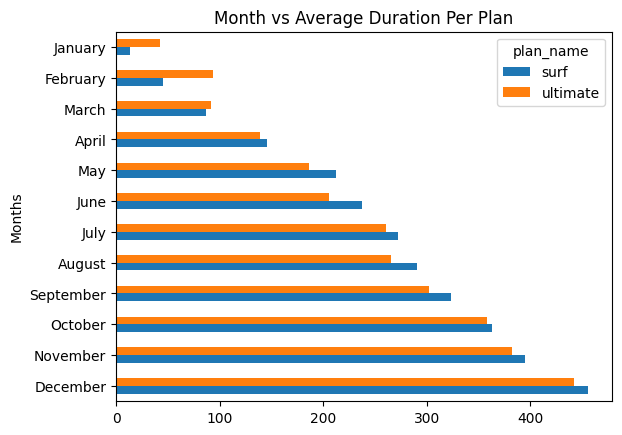

In [ ]:
# Compare average duration of calls per each plan per each distinct month. Plot a bar plot to visualize it.

avg_duration = df_user_monthly.pivot_table(index='month',
                                           columns='plan_name',
                                           values = 'total_of_mins',
                                           aggfunc='mean')
month_ordered = ['January', 'February', 'March',
               'April', 'May', 'June',
               'July', 'August', 'September',
               'October', 'November', 'December']
month_ordered = month_ordered[::-1]

avg_duration = avg_duration.reindex(month_ordered)

avg_duration.plot(kind='barh',
                  xlabel='Months',
                  ylabel='Average Duration (minutes)',
                  title='Month vs Average Duration Per Plan')
plt.show()

-----

Based on the bar chart, the Surf plan appears to have a higher average monthly call duration than the Ultimate plan for most months.

The Ultimate plan only exceeds the Surf plan from January to March. In the remaining months, the Surf plan shows higher average call minutes.

However, this chart reflects average call duration and not revenue. To determine which plan generates more revenue, a separate revenue analysis would be needed.

-----

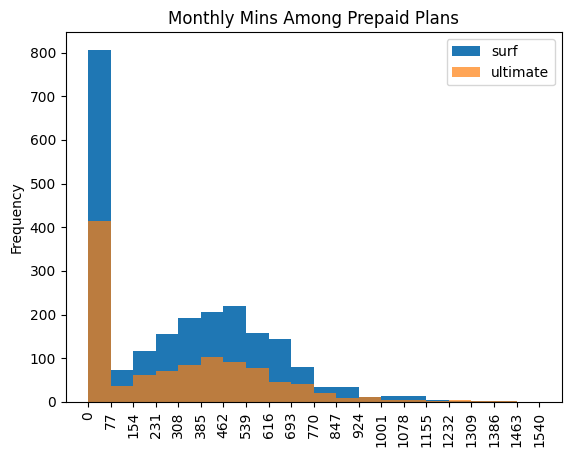

,surf freq,ultimate freq,rel freq surf %,rel freq ultimate %,cdf surf %,cdf ultimate %
intervals minutes,,,,,,
"[0,77)",806,414,35.57,38.05,35.57,38.05
"[77,154)",74,37,3.27,3.40,38.83,41.45
"[154,231)",117,62,5.16,5.70,44.00,47.15
"[231,308)",155,71,6.84,6.53,50.84,53.68
"[308,385)",191,84,8.43,7.72,59.27,61.40
"[385,462)",205,103,9.05,9.47,68.31,70.86
"[462,539)",220,92,9.71,8.46,78.02,79.32
"[539,616)",158,77,6.97,7.08,85.00,86.40
"[616,693)",144,46,6.35,4.23,91.35,90.62


In [ ]:
# Compare the number of minutes users of each plan require each month. Plot a histogram.

max_ = int(df_user_monthly['total_of_mins'].max())
min_ = int(df_user_monthly['total_of_mins'].min())
range_ = max_ - min_
bin_number = 20
width = int(range_ / bin_number)
bins = range(min_,max_ +1, width)


bin_labels = [f"[{bins[x]},{bins[x+1]})" for x in range(len(bins)-1)] # bin labels
surf_users_m = surf_people['total_of_mins']
ultimate_users_m = ultimate_people['total_of_mins']
surf_counts = [sum( (surf_users_m>=bins[x]) & (surf_users_m<bins[x+1])) for x in range(len(bins)-1) ]
ultimate_counts = [sum( (ultimate_users_m>=bins[x]) & (ultimate_users_m<bins[x+1])) for x in range(len(bins)-1) ]
data = {'intervals minutes':bin_labels,
        'surf freq':surf_counts,
        'ultimate freq':ultimate_counts}
mins_freq_table = pd.DataFrame(data)
mins_freq_table = mins_freq_table.set_index('intervals minutes')
mins_freq_table['rel freq surf %'] = round(mins_freq_table['surf freq']/mins_freq_table['surf freq'].sum(),4)*100
mins_freq_table['rel freq ultimate %'] = round(mins_freq_table['ultimate freq']/mins_freq_table['ultimate freq'].sum(),4)*100
mins_freq_table['cdf surf %'] = round(mins_freq_table['surf freq'].cumsum() / mins_freq_table['surf freq'].sum(),4)*100
mins_freq_table['cdf ultimate %'] = round(mins_freq_table['ultimate freq'].cumsum() / mins_freq_table['ultimate freq'].sum(),4)*100

surf_users_m.plot(kind='hist',bins=bins)
ultimate_users_m.plot(kind='hist',alpha=.7,bins=bins,rot=90, title="Monthly Mins Among Prepaid Plans")
plt.xticks(bins)
plt.legend(['surf','ultimate'])
plt.show()
mins_freq_table

-----


The distributions of total monthly minutes for both plans have very similar shapes based on the histograms. Both distributions are right-skewed, with a large concentration of users in the lowest usage interval (0–76 minutes).

Approximately 35.57% of Surf users and 38.05% of Ultimate users fall within the 0–76 minute range.

Additionally, about 95% of users in both plans used fewer than 770 minutes per month, as indicated by the cumulative distribution percentages.

It is also worth noting that no Ultimate user exceeded 3000 monthly minutes (the plan limit).

Overall, the usage patterns between the two plans appear very similar. However, while the distributions are similar, we cannot conclude that the monthly minute requirements are identical without conducting a statistical test.


-----

In [ ]:
# Calculate the mean and the variance of the monthly call duration

df_user_monthly.head()

,user_id,month,total_of_mb,total_of_messages,total_of_mins,total_calls_made,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,monthly_rev
0,1000,December,1901.47,11.0,124.0,16.0,1000,30720,3000,70,7,0.01,0.01,ultimate,70.00
1,1001,August,6919.15,30.0,187.0,27.0,50,15360,500,20,10,0.03,0.03,surf,20.00
2,1001,December,19369.18,44.0,422.0,56.0,50,15360,500,20,10,0.03,0.03,surf,60.00
3,1001,November,18504.30,36.0,441.0,64.0,50,15360,500,20,10,0.03,0.03,surf,60.00
4,1001,October,22330.49,53.0,411.0,65.0,50,15360,500,20,10,0.03,0.03,surf,90.09


In [ ]:
## surf ##
surf_people = df_user_monthly.query("plan_name == 'surf' ")
mean_duration_surf = np.mean(surf_people['total_of_mins'])
var_duration_surf = np.var(surf_people['total_of_mins'],ddof=1)
sd_duration_surf = np.std(surf_people['total_of_mins'],ddof=1)

## ultimate ##
ultimate_people = df_user_monthly.query("plan_name == 'ultimate' ")
mean_duration_ultimate = np.mean(ultimate_people['total_of_mins'])
var_duration_ultimate = np.var(ultimate_people['total_of_mins'],ddof=1)
sd_duration_ultimate = np.std(ultimate_people['total_of_mins'],ddof=1)

summary = {'average':[mean_duration_surf,mean_duration_ultimate],
           'variance': [var_duration_surf,var_duration_ultimate],
           'standard dev':[sd_duration_surf,sd_duration_ultimate]}

for name,metric in summary.items():
    print(f"Surf {name} monthly call duration: {metric[0]:.2f} mins\nUltimate {name} monthly call duration: {metric[1]:.2f} mins\n\n")

Surf average monthly call duration: 305.53 mins
Ultimate average monthly call duration: 292.79 mins


Surf variance monthly call duration: 81261.11 mins
Ultimate variance monthly call duration: 84121.22 mins


Surf standard dev monthly call duration: 285.06 mins
Ultimate standard dev monthly call duration: 290.04 mins




-----

The Surf and Ultimate prepaid plans have very similar averages, variances, and standard deviations for monthly call duration.

The average monthly call duration is 305.53 minutes for Surf users and 292.79 minutes for Ultimate users. The variability is also nearly identical, with standard deviations of 285.06 minutes (Surf) and 290.04 minutes (Ultimate).

This suggests that the overall distribution of monthly call usage is very similar across the two plans.


-----

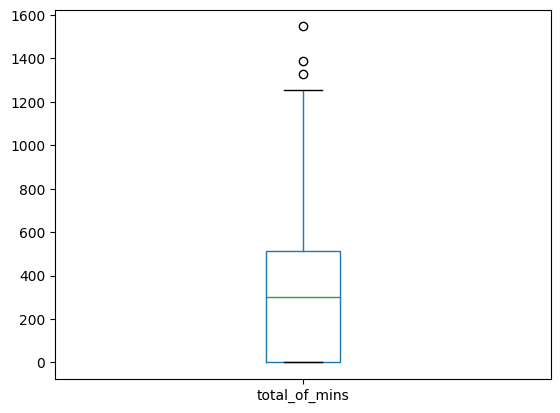

In [ ]:
# Plot a boxplot to visualize the distribution of the monthly call duration

surf_people['total_of_mins'].plot(kind='box')
plt.show()

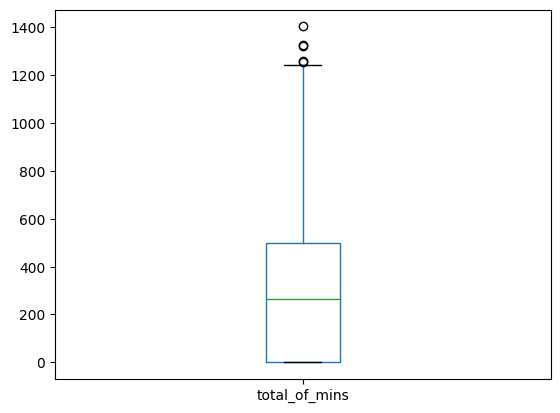

In [ ]:
ultimate_people['total_of_mins'].plot(kind='box')
plt.show()

-----


Both boxplots have very similar shapes and are right-skewed and there seem to be three high end outliers in both plans, indicating that a small number of users consume  more minutes than the majority.

The right skew also suggests that most users spend relatively few minutes on calls per month, while a smaller group uses very high amounts of minutes.

Based on the boxplots alone, it is difficult to determine which prepaid plan generates more revenue. Overall, user calling behavior appears very similar between the Surf and Ultimate plans in terms of monthly call duration.


-----

### Messages

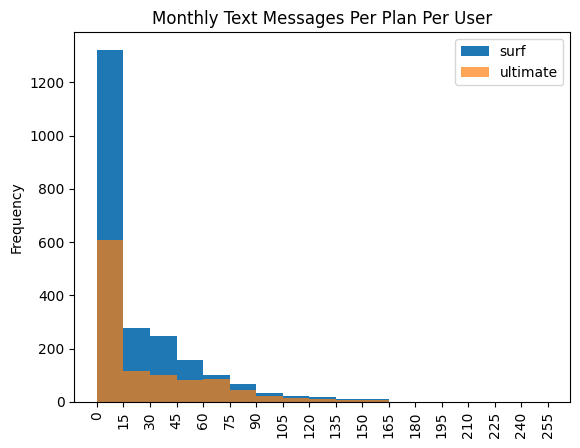

,surf freq,ultimate freq,rel freq surf %,rel freq ultimate %,cdf surf %,cdf ultimate %
intervals messages,,,,,,
"[0,15)",1322,607,58.34,55.79,58.34,55.79
"[15,30)",278,115,12.27,10.57,70.61,66.36
"[30,45)",246,99,10.86,9.10,81.47,75.46
"[45,60)",157,81,6.93,7.44,88.39,82.90
"[60,75)",101,85,4.46,7.81,92.85,90.72
"[75,90)",65,46,2.87,4.23,95.72,94.94
"[90,105)",34,20,1.50,1.84,97.22,96.78
"[105,120)",20,13,0.88,1.19,98.10,97.98
"[120,135)",19,10,0.84,0.92,98.94,98.90


In [ ]:
# Compare the number of messages users of each plan tend to send each month

max_ = int(df_user_monthly['total_of_messages'].max())
min_ = int(df_user_monthly['total_of_messages'].min())
range_ = max_ - min_
bin_number = 17
width = int(range_ / bin_number)
bins = range(min_,max_ +1, width)


bin_labels = [f"[{bins[x]},{bins[x+1]})" for x in range(len(bins)-1)] # bin labels
surf_users_ms = surf_people['total_of_messages']
ultimate_users_ms = ultimate_people['total_of_messages']
surf_counts = [sum( (surf_users_ms>=bins[x]) & (surf_users_ms<bins[x+1])) for x in range(len(bins)-1) ]
ultimate_counts = [sum( (ultimate_users_ms>=bins[x]) & (ultimate_users_ms<bins[x+1])) for x in range(len(bins)-1) ]
data = {'intervals messages':bin_labels,
        'surf freq':surf_counts,
        'ultimate freq':ultimate_counts}
m_freq_table = pd.DataFrame(data)
m_freq_table = m_freq_table.set_index('intervals messages')
m_freq_table['rel freq surf %'] = round(m_freq_table['surf freq']/m_freq_table['surf freq'].sum(),4)*100
m_freq_table['rel freq ultimate %'] = round(m_freq_table['ultimate freq']/m_freq_table['ultimate freq'].sum(),4)*100
m_freq_table['cdf surf %'] = round(m_freq_table['surf freq'].cumsum() / m_freq_table['surf freq'].sum(),4)*100
m_freq_table['cdf ultimate %'] = round(m_freq_table['ultimate freq'].cumsum() / m_freq_table['ultimate freq'].sum(),4)*100

surf_users_ms.plot(kind='hist',
                                      bins=bins)
ultimate_users_ms.plot(kind='hist',alpha=.7,bins=bins,rot=90,title='Monthly Text Messages Per Plan Per User')
plt.xticks(bins)
plt.legend(['surf','ultimate'])
plt.show()
m_freq_table

-----

Both plans show very similar distributions for the number of monthly text messages sent. The distributions are strongly right-skewed, with a large concentration of users in the 0–14 message interval.

The relative frequencies across bins are very similar for both Surf and Ultimate users. In fact, approximately half of users in each plan send fewer than 15 messages per month.

This indicates that the majority of users send relatively few text messages each month.

Additionally, none of the Ultimate plan users exceed their included text limit, suggesting that overage charges from messaging are unlikely for that plan.

-----

-----

Based on the histograms and frequency tables, we can conclude that users behave similarly in terms of messaging across both plans.
The shapes of the distributions in the histograms and boxplots are very similar, and the relative frequencies across intervals are nearly identical. This suggests that messaging behavior does not differ between the Surf and Ultimate plans.

-----

,user_id,month,total_of_mb,total_of_messages,total_of_mins,total_calls_made,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,monthly_rev
0,1000,December,1901.47,11.0,124.0,16.0,1000,30720,3000,70,7,0.01,0.01,ultimate,70.00
1,1001,August,6919.15,30.0,187.0,27.0,50,15360,500,20,10,0.03,0.03,surf,20.00
2,1001,December,19369.18,44.0,422.0,56.0,50,15360,500,20,10,0.03,0.03,surf,60.00
3,1001,November,18504.30,36.0,441.0,64.0,50,15360,500,20,10,0.03,0.03,surf,60.00
4,1001,October,22330.49,53.0,411.0,65.0,50,15360,500,20,10,0.03,0.03,surf,90.09


### Internet

In [ ]:
surf_people['total_of_gb'] = np.ceil(surf_people['total_of_mb']/1024)
ultimate_people['total_of_gb'] = np.ceil(ultimate_people['total_of_mb']/1024)
df_user_monthly['total_of_gb'] = np.ceil(df_user_monthly['total_of_mb']/1024)

/tmp/ipykernel_33/1414694586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  surf_people['total_of_gb'] = np.ceil(surf_people['total_of_mb']/1024)
/tmp/ipykernel_33/1414694586.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ultimate_people['total_of_gb'] = np.ceil(ultimate_people['total_of_mb']/1024)


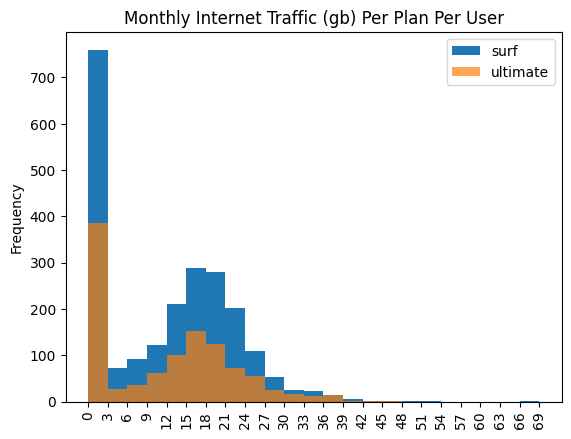

,surf freq,ultimate freq,rel freq surf %,rel freq ultimate %,cdf surf %,cdf ultimate %
intervals gb,,,,,,
"[0,3)",760,386,33.54,35.48,33.54,35.48
"[3,6)",73,28,3.22,2.57,36.76,38.05
"[6,9)",92,35,4.06,3.22,40.82,41.27
"[9,12)",123,61,5.43,5.61,46.25,46.88
"[12,15)",211,100,9.31,9.19,55.56,56.07
"[15,18)",288,153,12.71,14.06,68.27,70.13
"[18,21)",279,125,12.31,11.49,80.58,81.62
"[21,24)",203,72,8.96,6.62,89.54,88.24
"[24,27)",109,56,4.81,5.15,94.35,93.38


In [ ]:
# Compare the amount of internet traffic consumed by users per plan

max_ = int(df_user_monthly['total_of_gb'].max())
min_ = int(df_user_monthly['total_of_gb'].min())
range_ = max_ - min_
bin_number = 20
width = int(range_ / bin_number)
bins = range(min_,max_ +1, width)


bin_labels = [f"[{bins[x]},{bins[x+1]})" for x in range(len(bins)-1)] # bin labels
surf_users_gb = surf_people['total_of_gb']
ultimate_users_gb = ultimate_people['total_of_gb']
surf_counts = [sum( (surf_users_gb>=bins[x]) & (surf_users_gb<bins[x+1])) for x in range(len(bins)-1) ]
ultimate_counts = [sum( (ultimate_users_gb>=bins[x]) & (ultimate_users_gb<bins[x+1])) for x in range(len(bins)-1) ]
data = {'intervals gb':bin_labels,
        'surf freq':surf_counts,
        'ultimate freq':ultimate_counts}
gb_freq_table = pd.DataFrame(data)
gb_freq_table = gb_freq_table.set_index('intervals gb')
gb_freq_table['rel freq surf %'] = round(gb_freq_table['surf freq']/gb_freq_table['surf freq'].sum(),4)*100
gb_freq_table['rel freq ultimate %'] = round(gb_freq_table['ultimate freq']/gb_freq_table['ultimate freq'].sum(),4)*100
gb_freq_table['cdf surf %'] = round(gb_freq_table['surf freq'].cumsum() / gb_freq_table['surf freq'].sum(),4)*100
gb_freq_table['cdf ultimate %'] = round(gb_freq_table['ultimate freq'].cumsum() / gb_freq_table['ultimate freq'].sum(),4)*100


surf_users_gb.plot(kind='hist',bins=bins)
ultimate_users_gb.plot(kind='hist',alpha=.7,bins=bins,rot=90,title='Monthly Internet Traffic (gb) Per Plan Per User')

plt.xticks(bins)
plt.legend(['surf','ultimate'])
plt.show()
gb_freq_table

In [ ]:
## surf ##
mean_duration_surf = np.mean(surf_people['total_of_gb'])
var_duration_surf = np.var(surf_people['total_of_gb'],ddof=1)
sd_duration_surf = np.std(surf_people['total_of_gb'],ddof=1)

## ultimate ##
mean_duration_ultimate = np.mean(ultimate_people['total_of_gb'])
var_duration_ultimate = np.var(ultimate_people['total_of_gb'],ddof=1)
sd_duration_ultimate = np.std(ultimate_people['total_of_gb'],ddof=1)

summary = {'average':[mean_duration_surf,mean_duration_ultimate],
           'variance': [var_duration_surf,var_duration_ultimate],
           'standard dev':[sd_duration_surf,sd_duration_ultimate]}

for name,metric in summary.items():
    print(f"Surf {name} monthly gb: {metric[0]:.2f} mins\nUltimate {name} monthly gb: {metric[1]:.2f} mins\n\n")

Surf average monthly gb: 11.57 mins
Ultimate average monthly gb: 11.45 mins


Surf variance monthly gb: 101.78 mins
Ultimate variance monthly gb: 106.02 mins


Surf standard dev monthly gb: 10.09 mins
Ultimate standard dev monthly gb: 10.30 mins




------

Both prepaid plans show very similar distributions of monthly internet usage. The frequency table and histogram indicate comparable patterns across Surf and Ultimate users.
There is a strong concentration of users in the lowest interval (0–2 GB).

After this initial concentration, usage gradually declines as data consumption increases, producing a right-skewed distribution,then a normal distribution. So there seem to be two clusters from the graph.

Converting plan limits:

15 GB = 15360 MB (Surf)

30 GB = 30720 MB (Ultimate)

Based on the cumulative distribution:
About 68% of Surf users uses less than 15 GB monthly.
About 96% of Ultimate users uses less than 30 GB monthly.

Overall, the distributions are highly similar in shape and spread. However, further analysis is required to determine whether differences in usage translate into meaningful revenue differences between the plans.

------



-----

Users on both the Surf and Ultimate plans have very similar internet consumption patterns,means, and variances. The distributions are highly comparable in shape and concentration, with most users consuming relatively low amounts of data each month regardless of plan.

-----

## Revenue

In [ ]:
df_user_monthly.groupby('plan_name').agg(total_rev = ('monthly_rev','sum'),
                                         mean_rev_monthly = ('monthly_rev','mean'),
                                         var_rev_monthly = ('monthly_rev',lambda x: np.var(x,ddof=1)),
                                         sd_rev_monthly = ('monthly_rev',lambda x: np.std(x,ddof=1)),
                                         max_rev_month = ('monthly_rev','max'),
                                         min_rev_month = ('monthly_rev','min') )




,total_rev,mean_rev_monthly,var_rev_monthly,sd_rev_monthly,max_rev_month,min_rev_month
plan_name,,,,,,
surf,109674.21,48.378566,2488.955844,49.889436,591.27,20.0
ultimate,77826.00,71.531250,87.088259,9.332109,182.00,70.0


In [ ]:
df_users['plan'].value_counts()

surf        339
ultimate    161
Name: plan, dtype: int64

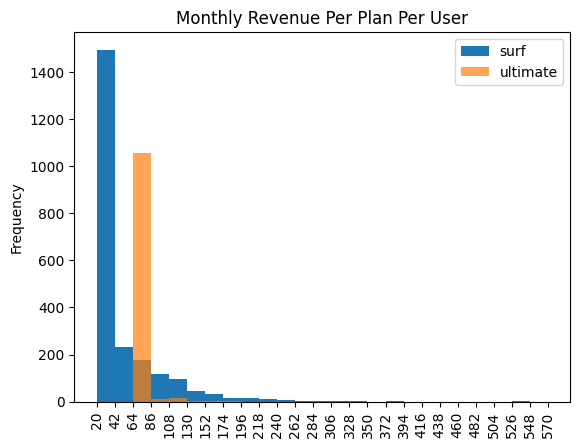

,surf freq,ultimate freq,rel freq surf %,rel freq ultimate %,cdf surf %,cdf ultimate %
intervals rev,,,,,,
"[20,42)",1495,0,65.98,0.00,65.98,0.00
"[42,64)",232,0,10.24,0.00,76.21,0.00
"[64,86)",177,1056,7.81,97.06,84.02,97.06
"[86,108)",119,11,5.25,1.01,89.28,98.07
"[108,130)",97,15,4.28,1.38,93.56,99.45
"[130,152)",47,2,2.07,0.18,95.63,99.63
"[152,174)",33,2,1.46,0.18,97.09,99.82
"[174,196)",14,2,0.62,0.18,97.71,100.00
"[196,218)",17,0,0.75,0.00,98.46,100.00


In [ ]:
# Compare rev by users per plan

max_ = int(df_user_monthly['monthly_rev'].max())
min_ = int(df_user_monthly['monthly_rev'].min())
range_ = max_ - min_
bin_number = 25
width = int(range_ / bin_number)
bins = range(min_,max_ +1, width)


bin_labels = [f"[{bins[x]},{bins[x+1]})" for x in range(len(bins)-1)] # bin labels
surf_users_rev = surf_people['monthly_rev']
ultimate_users_rev = ultimate_people['monthly_rev']
surf_counts = [sum( (surf_users_rev>=bins[x]) & (surf_users_rev<bins[x+1])) for x in range(len(bins)-1) ]
ultimate_counts = [sum( (ultimate_users_rev>=bins[x]) & (ultimate_users_rev<bins[x+1])) for x in range(len(bins)-1) ]
data = {'intervals rev':bin_labels,
        'surf freq':surf_counts,
        'ultimate freq':ultimate_counts}
rev_freq_table = pd.DataFrame(data)
rev_freq_table = rev_freq_table.set_index('intervals rev')
rev_freq_table['rel freq surf %'] = round(rev_freq_table['surf freq']/rev_freq_table['surf freq'].sum(),4)*100
rev_freq_table['rel freq ultimate %'] = round(rev_freq_table['ultimate freq']/rev_freq_table['ultimate freq'].sum(),4)*100
rev_freq_table['cdf surf %'] = round(rev_freq_table['surf freq'].cumsum() / rev_freq_table['surf freq'].sum(),4)*100
rev_freq_table['cdf ultimate %'] = round(rev_freq_table['ultimate freq'].cumsum() / rev_freq_table['ultimate freq'].sum(),4)*100


surf_users_rev.plot(kind='hist',bins=bins)
ultimate_users_rev.plot(kind='hist',alpha=.7,bins=bins,rot=90,title='Monthly Revenue Per Plan Per User')

plt.xticks(bins)
plt.legend(['surf','ultimate'])
plt.show()
rev_freq_table

-----

In 2018, the Surf prepaid plan generated a total revenue of 109674.21, while the Ultimate prepaid plan generated 77826.00.
Therefore, Surf produced higher overall revenue during the year.

However, it is important to note that the sample was imbalanced because out of 500 users, 339 were Surf users. This larger representation likely contributed to the higher total revenue observed for the Surf plan.

In contrast, the Ultimate plan generated more consistent monthly revenue, reflected by its much lower standard deviation (approximately 7). This suggests that Ultimate revenue is more stable and predictable from month to month.

While Surf currently brings in higher total revenue, the Ultimate plan may offer greater revenue predictability, which could be beneficial for budgeting and financial planning decisions, including advertising.


-----

## Test statistical hypotheses

In [ ]:
# Test the hypotheses

H0: mu_surf = mu_ultimate -> mu_surf - mu_ultimate = 0

Ha: mu_surf != mu_ultimate -> mu_surf - mu_ultimate != 0

In [ ]:
## defining variables ##

mean_rev_surf = np.mean(surf_users_rev)
mean_rev_ultimate = np.mean(ultimate_users_rev)
mean_diff = mean_rev_surf - mean_rev_ultimate
n_surf = len(surf_users_rev)
n_ultimate = len(ultimate_users_rev)

sd_rev_surf = np.std(surf_users_rev,ddof=1)
sd_rev_ultimate = np.std(ultimate_users_rev,ddof=1)
var_rev_surf = np.var(surf_users_rev,ddof=1)
var_rev_ultimate = np.var(ultimate_users_rev,ddof=1)
f = var_rev_surf/var_rev_ultimate if var_rev_surf>var_rev_ultimate else var_rev_ultimate/var_rev_surf

alpha = 0.05
print(var_rev_surf,var_rev_ultimate)

2488.955844060353 87.08825896964122


In [ ]:
cv_f = st.f.ppf(1-alpha/2,n_surf-1,n_ultimate-1) # critical value f

if f <= cv_f:
    print('pool')
    df = n_surf + n_ultimate - 2 # degree of freedoms
else:
    print('dont pool')
    top = np.square(var_rev_surf/n_surf + var_rev_ultimate/n_ultimate)
    bottom = np.square(var_rev_surf/n_surf)/(n_surf-1) + np.square(var_rev_ultimate/n_ultimate)/(n_ultimate-1)
    df = top/bottom

dont pool


In [ ]:
se = np.sqrt(var_rev_surf/n_surf + var_rev_ultimate/n_ultimate)
test_statistic = (mean_rev_surf-mean_rev_ultimate)/ se
p_value = 2*st.t.sf(abs(test_statistic),df)
if p_value <= alpha:
    print('reject h0')
else:
    print('fail to reject h0')
print(p_value,test_statistic)

reject h0
3.980194394745487e-93 -21.33229613895376


In [ ]:
se = np.sqrt(var_rev_surf/n_surf + var_rev_ultimate/n_ultimate) # standard error
test_statisic = (mean_rev_surf-mean_rev_ultimate)/se

p_value = 2*(st.t.sf(abs(test_statisic),df))

if p_value < alpha:
    print('reject H0')
else:
    print("fail to reject H0")

reject H0


In [ ]:

## confidence interval ##
t_cv = st.t.ppf(1-alpha/2,df)
margin_error = t_cv*se
upper_limit = round(mean_diff + margin_error,2)
lower_limit = round(mean_diff - margin_error,2)
print(lower_limit,upper_limit)

-25.28 -21.02


-----

At the 5% significance level ( 0.05), the p-value is  2.98 x 10^-93, which is 0 and less than 0.05. Therefore, we reject the null hypothesis.

There is strong statistical evidence that the average monthly revenue from users of the Surf and Ultimate calling plans is significantly different.

The negative test statistic indicates that the average monthly revenue for Surf users is significantly lower than that for Ultimate users.

We are 95% confident that the true difference in average monthly revenue (Surf − Ultimate) lies between −25.28 and −21.02 dollars.
This means that on average, the Ultimate prepaid plan generates between 21.02 and 25.28 more per month per user than the Surf prepaid plan.


-----

In [ ]:
# Test the hypotheses

df_user_monthly.head()

,user_id,month,total_of_mb,total_of_messages,total_of_mins,total_calls_made,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,monthly_rev,total_of_gb
0,1000,December,1901.47,11.0,124.0,16.0,1000,30720,3000,70,7,0.01,0.01,ultimate,70.00,2.0
1,1001,August,6919.15,30.0,187.0,27.0,50,15360,500,20,10,0.03,0.03,surf,20.00,7.0
2,1001,December,19369.18,44.0,422.0,56.0,50,15360,500,20,10,0.03,0.03,surf,60.00,19.0
3,1001,November,18504.30,36.0,441.0,64.0,50,15360,500,20,10,0.03,0.03,surf,60.00,19.0
4,1001,October,22330.49,53.0,411.0,65.0,50,15360,500,20,10,0.03,0.03,surf,90.09,22.0


In [ ]:
df_user_monthly = pd.merge(df_user_monthly,df_users[['user_id','city']],
                           on = 'user_id',
                           how='left')

In [ ]:
ny_nj = 'New York-Newark-Jersey City, NY-NJ-PA MSA'
ny_nj_users = df_user_monthly.query("city == @ny_nj")['monthly_rev']
non_ny_nj_users = df_user_monthly.query("city != @ny_nj")['monthly_rev']

H0: mu_ny_nj = mu_non_ny_nj -> mu_ny_nj - mu_non_ny_nj = 0

Ha: mu_ny_nj != mu_non_ny_nj -> mu_ny_nj - mu_non_ny_nj != 0

In [ ]:
## defining variables ##

mean_rev_nynj = np.mean(ny_nj_users)
mean_rev_non_nynj = np.mean(non_ny_nj_users)
mean_diff = mean_rev_nynj - mean_rev_non_nynj
n_nynj = len(ny_nj_users)
n_non_nynj = len(non_ny_nj_users)

sd_rev_nynj = np.std(ny_nj_users,ddof=1)
sd_rev_non_nynj = np.std(non_ny_nj_users,ddof=1)
var_rev_nynj = np.var(ny_nj_users,ddof=1)
var_rev_non_nynj = np.var(non_ny_nj_users,ddof=1)
f = var_rev_nynj/var_rev_non_nynj if var_rev_nynj>var_rev_non_nynj else var_rev_non_nynj/var_rev_nynj

alpha = 0.05
print(var_rev_nynj,var_rev_non_nynj)

1593.6264458441829 1871.0980292181594


In [ ]:
cv_f = st.f.ppf(1-alpha/2,n_non_nynj-1,n_nynj-1) # critical value f

if f <= cv_f:
    print('pool')
    df = n_nynj + n_non_nynj - 2 # degree of freedoms
else:
    print('dont pool')
    top = np.square(var_rev_nynj/n_nynj + var_rev_non_nynj/n_non_nynj)
    bottom = np.square(var_rev_nynj/n_nynj)/(n_nynj-1) + np.square(var_rev_non_nynj/n_non_nynj)/(n_non_nynj-1)
    df = top/bottom

dont pool


In [ ]:
se = np.sqrt(var_rev_nynj/n_nynj + var_rev_non_nynj/n_non_nynj)
test_statistic = (mean_rev_nynj-mean_rev_non_nynj)/ se
p_value = 2*st.t.sf(abs(test_statistic),df)
if p_value <= alpha:
    print('reject h0')
else:
    print('fail to reject h0')
print(p_value,test_statistic)

reject h0
0.029237448601445608 -2.184070543154842


In [ ]:
## confidence interval ##
t_cv = st.t.ppf(1-alpha/2,df)
margin_error = t_cv*se
upper_limit = round(mean_diff + margin_error,2)
lower_limit = round(mean_diff - margin_error,2)
print(lower_limit,upper_limit)

-7.82 -0.42


-----

At the 5% significance level (0.05), the p-value is 0.029, which is less than 0.05.
Therefore, we reject the null hypothesis.

There is statistically significant evidence that the average monthly revenue from users in NY/NJ differs from that of users outside NY/NJ.

The data also suggest that users outside NY/NJ generate slightly higher average monthly revenue than users in NY/NJ.

With 95% confidence, customers outside the NY/NJ region generate between 0.42 and 5.12 more in average monthly revenue than customers within NY/NJ.

-----

## General conclusion



-----

**Internet Usage Behavior**

Both Surf and Ultimate users showed similar internet traffic patterns. The distributions were  right-skewed with most users consuming relatively low amounts of data per month.


-----

-----

**Revenue by Plan**

Total annual revenue was higher for the Surf plan. However, the sample was imbalanced (more Surf users).

Did a two-sample t-test showed a statistically significant difference in average monthly revenue. The 95% confidence interval indicated that Ultimate users generate between 21.02 and 25.28 more per month per user than Surf users. While Surf produces higher total revenue due to having more users, The Ultimate plan generates significantly higher average monthly revenue per customer.

-----

-----

**Revenue by Region**

A two-sample t-test comparing NY/NJ users to users outside the region showed a statistically significant difference (p = 0.029). The 95% confidence interval indicates that users outside NY/NJ generate between 0.42 and 5.12 more per month than NY/NJ users. Geographic location has a statistically significant impact on revenue.

----

-----

**Business**

The Ultimate plan generates higher revenue per user and provides more predictable monthly revenue. The Surf plan generates greater total revenue due to its larger customer database. Regional differences exist but are relatively small compared to prepaid plan  differences. Marketing strategies may benefit from promoting Ultimate in regions with higher revenue potential.


-----